<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_222_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/tharindu33333/ME421-Mechanical-Systems-Lab-A2/tree/main/Vibration

## New Section

In [6]:
import numpy as np
import scipy as sp
from scipy.integrate import odeint
import math
from numpy import linalg
import sympy

from sympy import symbols
from sympy import *
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
init_vprinting(pretty_print=True)

import plotly.graph_objects as go

# Python Rigidbody Class Definition

In [19]:

import numpy as np
import plotly.graph_objects as go
import math

class MugasRigidBodyFunctions:

    def __init__(self):
        pass


    def hat_matrix(self, x):

        return np.array([
            [0., -x[2], x[1]],
            [x[2],  0., -x[0]],
            [-x[1], x[0],  0.]
        ])


    def q_from_axis_angles(self, theta, unit_axis):

        # Compute the scalar part of the quaternion (cosine of half the rotation angle)
        scalar_part = np.cos(theta / 2)

        # Compute the vector part of the quaternion (sine of half the rotation angle times the unit axis)
        three_by_one_matrix_part = np.sin(theta / 2) * np.array(unit_axis)

        # Combine scalar and vector parts into a single quaternion
        return np.concatenate(([scalar_part], three_by_one_matrix_part))


    def r_from_quaternions(self, q):

        # Extract the scalar part of the quaternion (q0)
        q0 = q[0]

        # Extract the direction part and reshape it into a 3x1 matrix
        w = q[1:] #.reshape((3, 1))

        # Compute the rotation matrix using the quaternion formula
        return (
            np.identity(3) +
            2 * q0 * self.hat_matrix(w) +
            2 * self.hat_matrix(w) @ self.hat_matrix(w)
        )


    def rotation_matrix_2_euler_angles(self, R):
               # Check the third row, third column element to determine the rotation scenario
        if R[2, 2] < 1:  # General case: not gimbal lock
            if R[2, 2] > -1:  # Unique solution
                phi = np.pi - math.atan2(R[0, 2], R[1, 2])  # Rotation about z-axis
                theta = math.acos(R[2, 2])  # Rotation about y-axis
                psi = np.pi - math.atan2(R[2, 0], -R[2, 1])  # Rotation about x-axis
                return phi, theta, psi
            # Gimbal lock: theta = π
            phi = -math.atan2(R[0, 1], -R[0, 0])  # Rotation about z-axis
            return phi, np.pi, 0
        # Gimbal lock: theta = 0
        phi = math.atan2(R[0, 1], R[0, 0])  # Rotation about z-axis
        return phi, 0, 0

    def re3_equals_gamma(self, gamma):

        # Compute the rotation angle (theta) between e3 and gamma
        theta = math.acos(gamma[2])

        # Handle edge case where gamma is already aligned with e3
        if np.isclose(np.sin(theta), 0):
            return np.identity(3)  # No rotation needed

        # Compute the rotation axis (n) as a 3x1 matrix
        n = np.array([[-gamma[1] / np.sin(theta)],
                      [gamma[0] / np.sin(theta)],
                      [0]])

        # Construct the quaternion and compute the rotation matrix
        return self.r_from_quaternions(self.q_from_axis_angles(theta, n))


    def rotate_and_translate(self, object_vertices, R, o):

        # Reshape the translation into a 3x1 matrix if not already in that form
        o = np.array([[o[0], o[1], o[2]]]).T

        # Apply the rotation and translation to the object vertices
        return o + R @ object_vertices

    def add_orth_norm_frame(self, fig, o, R, axis_range, axis_color):
               # Define the standard basis vectors for the x, y, and z axes
        e = [np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1])]

        # Apply the rotation matrix R to each e-frame axis to compute the rotated b-frame axes
        b = [R @ ei for ei in e]

        # Add each axis as a line starting at origin `o` and extending in the rotated direction
        for bi in b:
            fig.add_trace(go.Scatter3d(
                x=[o[0], o[0] + bi[0]],  # Line along the rotated axis
                y=[o[1], o[1] + bi[1]],
                z=[o[2], o[2] + bi[2]],
                hoverinfo='x+y+z',  # Tooltip displays the 3D coordinates
                mode='lines',  # Display as lines
                line=dict(width=8, color=axis_color)  # Line styling
            ))

        # Update the layout to fix the axis ranges and maintain aspect ratio
        fig.update_layout(
            showlegend=False,  # Hide legend
            scene=dict(
                xaxis=dict(range=axis_range[0], autorange=False),
                yaxis=dict(range=axis_range[1], autorange=False),
                zaxis=dict(range=axis_range[2], autorange=False),
                aspectratio=dict(x=1, y=1, z=1)  # Keep the aspect ratio uniform
            )
        )
        return fig

    def add_orth_norm_frame(self, fig, o, R, axis_range, axis_color):
              # Define the e-frame axis for the x, y, and z axes
        e = [np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1])]

        # Apply the rotation matrix R to each e-frame axis to compute the rotated b-frame axes
        b = [R @ ei for ei in e]

        # Add each axis as a line starting at origin `o` and extending in the rotated direction
        for bi in b:
            fig.add_trace(go.Scatter3d(
                x=[o[0], o[0] + bi[0]],  # Line along the rotated axis
                y=[o[1], o[1] + bi[1]],
                z=[o[2], o[2] + bi[2]],
                hoverinfo='x+y+z',  # Tooltip displays the 3D coordinates
                mode='lines',  # Display as lines
                line=dict(width=8, color=axis_color)  # Line styling
            ))

        # Update the layout to fix the axis ranges and maintain aspect ratio
        fig.update_layout(
            showlegend=False,  # Hide legend
            scene=dict(
                xaxis=dict(range=axis_range[0], autorange=False),
                yaxis=dict(range=axis_range[1], autorange=False),
                zaxis=dict(range=axis_range[2], autorange=False),
                aspectratio=dict(x=1, y=1, z=1)  # Keep the aspect ratio uniform
            )
        )
        return fig

    def animate_particle_motion(self, xx, axis_range, fig_title):

        # Unpack the particle's trajectory into separate x, y, z coordinates
        x_vals, y_vals, z_vals = zip(*xx)

        # Define the initial position of the particle as a red marker
        trace_particle = go.Scatter3d(
            x=[x_vals[0]], y=[y_vals[0]], z=[z_vals[0]],  # Start with the first position
            mode="markers",  # Show as a marker
            marker=dict(color="red", size=10)  # Red marker with size 10
        )

        # Define the complete trajectory as a blue line
        trace_path = go.Scatter3d(
            x=x_vals, y=y_vals, z=z_vals,  # All trajectory points
            mode="lines",  # Show as a line
            line=dict(color="blue", width=2),  # Blue line with width 2
            name='Path'
        )

        # Define the layout of the plot
        layout = go.Layout(
            title_text=fig_title,  # Title of the figure
            hovermode="closest",  # Tooltip shows closest data point
            updatemenus=[dict(
                type="buttons",
                buttons=[dict(
                    label="Play",  # Play button for the animation
                    method="animate",
                    args=[None]
                )]
            )],
            scene=dict(  # 3D scene settings
                xaxis=dict(range=axis_range[0], autorange=False),  # Fixed x-axis range
                yaxis=dict(range=axis_range[1], autorange=False),  # Fixed y-axis range
                zaxis=dict(range=axis_range[2], autorange=False),  # Fixed z-axis range
                aspectratio=dict(x=1, y=1, z=1)  # Uniform aspect ratio
            )
        )

        # Create animation frames for each point in the trajectory
        frames = [go.Frame(
            data=[go.Scatter3d(
                x=[point[0]], y=[point[1]], z=[point[2]],  # Current position of the particle
                mode="markers",  # Show as a marker
                marker=dict(color="red", size=10),  # Red marker with size 10
                name='Particle'
            )]) for point in xx]

        # Create the Plotly figure with initial data, layout, and frames
        fig = go.Figure(data=[trace_particle, trace_path], layout=layout, frames=frames)

        # Display the figure
        fig.show()

        # Return the figure object
        return fig

    def rigid_body_system(self, parameters, t, X):

        # Extract parameters
        barX, M = parameters['CM'], parameters['M']

        # Extract state variables
        R = X[0][0]  # Rotation matrix
        omega = X[1]  # Spatial angular velocity
        p = X[2]  # Linear momentum

        # Compute external and actuator forces and torques
        taue, fe = externalForceModel(self, parameters, X)  # External forces and torques
        taua, fa = actuator(self, parameters, t, X, taue, fe)  # Actuator forces and torques

        # Compute time derivatives of position, momentum, and spin
        doto = p / M  # Time derivative of position
        dp = fe + fa  # Time derivative of linear momentum
        dspi = taue + taua  # Time derivative of spin

        # External dynamics (can be expanded with a controller model)
        dXc = np.array([0., 0., 0.])

        # Compute angular velocity properties
        if np.linalg.norm(omega) >= 0.0001:  # Avoid division by zero
            nomega = omega / np.linalg.norm(omega)  # Normalized angular velocity
            thetaomega = np.linalg.norm(omega)  # Magnitude of angular velocity
        else:  # Handle case of negligible angular velocity
            nomega = np.array([0, 0, 0])
            thetaomega = 0

        # Return computed quantities
        return [thetaomega, nomega, doto, dp, dspi, dXc]


    def animate_2D_scatter_plot(self, x, YY, xlabel, ylabel, title):

        # Define the layout of the plot
        layout = go.Layout(
            xaxis={'title': xlabel},  # Label for the x-axis
            yaxis={'title': ylabel, 'range': [1.1 * YY.min(), 1.1 * YY.max()]},  # Label and range for the y-axis
            title={'text': title, 'y': 0.9, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'},  # Title styling
            scene=dict(aspectratio=dict(x=1, y=1)),  # Maintain aspect ratio
            hovermode="closest",  # Display closest data point information
            updatemenus=[dict(
                type="buttons",
                buttons=[
                    dict(
                        label="Play",  # Animation play button
                        method="animate",
                        args=[None]
                    )
                ]
            )]
        )

        # Create frames for each time step in YY
        frames = [go.Frame(data=[go.Scatter(x=x, y=y)]) for y in YY]

        # Initialize the figure with the first frame's data and the layout
        fig = go.Figure(data=[go.Scatter(x=x, y=YY[0, :])], layout=layout, frames=frames)

        # Return the figure object (can be displayed using fig.show())
        return fig


    def simulate_dy_system(self, dynamic_system_model, t_max, dt, x0, sys_para, fig_title, x_label, y_label):

        # Generate time points for the simulation
        t = np.linspace(0, t_max, int(t_max / dt + 1))

        # Solve the system of differential equations
        sol = odeint(dynamic_system_model, x0, t, args=(sys_para,))

        # Create a Plotly figure for visualization
        fig = go.Figure()

        # Add a line plot for each state variable
        for sol_col in sol.T:
            fig.add_trace(go.Scatter(x=t, y=sol_col, mode='lines+markers'))

        # Update the figure layout with titles and axis labels
        fig.update_layout(
            title=fig_title,
            xaxis=dict(title=x_label),
            yaxis=dict(title=y_label)
        )

        # Display the figure
        fig.show()

        # Return the time points, solution matrix, and figure
        return t, sol, fig

    def LinearSystemModel(self, X, t, A):
                # Compute the time derivative of the state vector using the system matrix
        dXdt = A @ X
        return dXdt


    def cube_vertices(self, cube_dimensions):
        l, w, h = cube_dimensions['l'], cube_dimensions['w'], cube_dimensions['h']
        xp, yp, zp = cube_dimensions['xp'], cube_dimensions['yp'], cube_dimensions['zp']

        X = [-xp, -xp, l-xp, l-xp, -xp, -xp, l-xp, l-xp]
        Y = [-yp, w-yp, w-yp, -yp, -yp, w-yp, w-yp, -yp]
        Z = [-zp, -zp, -zp, -zp, h-zp, h-zp, h-zp, h-zp]

        return [X, Y, Z]

    def animated_cube_flat_shading(self, cubeVertices,figTitle):
        fig = go.Figure(
            frames=[go.Frame(data=[
            go.Mesh3d(
                # 8 vertices of a cube
                x=xx[0][0],
                y=xx[0][1],
                z=xx[0][2],
                # i, j and k give the vertices of triangles
                i = [7, 0, 0, 0, 4, 4, 6, 6, 4, 0, 3, 2],
                j = [3, 4, 1, 2, 5, 6, 5, 2, 0, 1, 6, 3],
                k = [0, 7, 2, 3, 6, 7, 1, 1, 5, 5, 7, 6],
                name='y',
                opacity=0.6,
                color='#DC143C',
                flatshading = True)]) for xx in cubeVertices])

        fig.add_trace(go.Mesh3d(
                # 8 vertices of a cube
                x=cubeVertices[0][0][0],
                y=cubeVertices[0][0][1],
                z=cubeVertices[0][0][2],
                # i, j and k give the vertices of triangles
                i = [7, 0, 0, 0, 4, 4, 6, 6, 4, 0, 3, 2],
                j = [3, 4, 1, 2, 5, 6, 5, 2, 0, 1, 6, 3],
                k = [0, 7, 2, 3, 6, 7, 1, 1, 5, 5, 7, 6],
                name='y',
                opacity=0.6,
                color='#DC143C',
                flatshading = True)
            )

        duration=10;
        fig.update_layout(
            title=figTitle,width=600,height=600,
            scene=dict(xaxis=dict(range=[-5., 5.], autorange=False),yaxis=dict(range=[-5., 5.], autorange=False),zaxis=dict(range=[-5., 5.], autorange=False),aspectratio=dict(x=1, y=1, z=1),),
            updatemenus=[dict(type="buttons",
                                buttons=[dict(label="Play",
                                                method="animate",
                                                args=[None, {"frame": {"duration": duration},"mode": "immediate","fromcurrent": True, "transition": {"duration": duration, "easing": "linear"},}]
                                                )])])
        len(fig.frames)
        fig.show()
        return fig


    def eulers_method(self, dt, Tmax, parameters, ICs):
        M, II = parameters['M'], parameters['II']
        invII = np.linalg.inv(II)
        timeSteps = np.arange(0, Tmax+dt, dt)
        R, o, omega, doto, Xc = ICs[0][0], ICs[0][1], ICs[1], ICs[2], ICs[3]
        spi = R @ II @ R.T @ omega
        p = M * doto
        Xout = [ICs]

        for t in timeSteps:
            taue, fe = externalForceModel(self, parameters, X)
            taua, fa = actuator(self, parameters, t, X, taue, fe)

            dspi = taue + taua
            dp = fe + fa

            if np.linalg.norm(omega) >= 0.0001:
                nomega = omega / np.linalg.norm(omega)
                thetaomegat = dt * np.linalg.norm(omega)
                qomegat = np.concatenate(([np.cos(thetaomegat/2)], np.sin(thetaomegat/2) * nomega))
                R = self.r_from_quaternionsns(qomegat) @ R

            o += dt * doto
            spi += dt * dspi
            p += dt * dp
            doto = p / M
            omega = R @ invII @ R.T @ spi
            X = [[R, o], omega, doto, Xc]
            Xout.append(X)

        return Xout

    def runga_kutta_method(self, dt, Tmax, parameters, ICs):
        M, II = parameters['M'], parameters['II']
        invII = np.linalg.inv(II)
        timeSteps = np.arange(0, Tmax+dt, dt)
        X=ICs;
        Xout=[X];

        for t in timeSteps:
            Y1 = self.rk4_function(0.5*dt, X, t, X, parameters)
            Y2 = self.rk4_function(0.5*dt, X, t+0.5*dt, Y1, parameters)
            Y3 = self.rk4_function(dt, X, t+0.5*dt, Y2, parameters)

            values = [self.rigid_body_system(parameters, t+i*dt, X_j) for i, X_j in enumerate([X, Y1, Y2, Y3])]
            thetas, n_omegas, dotos, dps, dspis, dXcs = zip(*values)

            omegak = (dt/6.0) * sum(t * n for t, n in zip(thetas, n_omegas))
            nomegak = omegak/np.linalg.norm(omegak) if np.linalg.norm(omegak) >= 0.0001 else np.array([0, 0, 0])
            qomegak = np.concatenate(([np.cos(np.linalg.norm(omegak)/2)], np.sin(np.linalg.norm(omegak)/2) * nomegak))
            Rk = self.r_from_quaternions(qomegak) @ X[0][0]

            ok = X[0][1] + dt * np.mean(dotos)
            pk = X[2] + dt * np.mean(dps)
            spik = X[0][0] @ II @ X[0][0].T @ X[1] + dt * np.mean(dspis)
            Xck = X[3] + dt * np.mean(dXcs)

            omegak = Rk @ invII @ Rk.T @ spik
            X = [[Rk, ok], omegak, pk, Xck]
            Xout.append(X)

        return Xout

    def rk4_function(self, dtk, X, tk, Xk, parameters):
        M, II = parameters['M'], parameters['II']
        thetaomega1, nomega1, doto1, dp1, dspi1, dXc1 = self.rigid_body_system(parameters, tk, Xk)
        qomega1 = np.concatenate(([np.cos(dtk*thetaomega1/2)], np.sin(dtk*thetaomega1/2) * nomega1))
        R1 = self.r_from_quaternions(qomega1) @ X[0][0]
        p1 = X[2] + dtk * dp1
        spi1 = X[0][0] @ II @ X[0][0].T @ X[1] + dtk * dspi1
        omega1 = R1 @ np.linalg.inv(II) @ R1.T @ spi1
        X1 = [[R1, X[0][1] + dtk * doto1], omega1, p1, X[3] + dtk * dXc1]
        return X1


    def simulating_a_cube(self, dt, Tmax, cubeDimensions, parameters,ICs):
        XX=self.cube_vertices(cubeDimensions);

        #Xs=self.eulers_method(dt,Tmax,parameters,ICs);
        Xs=self.runga_kutta_method(dt,Tmax,parameters,ICs);
        ICR=ICs[0][0];
        XX0=ICR @ XX;

        rotatedVertices=[[XX0]]
        for X in Xs:
        #print(X[0])
            R=X[0][0];
            o=X[0][1];
            XXi=self.rotate_and_translate(XX,R,o);
            XX0=XXi;
            rotatedVertices+=[[XX0]];
        return rotatedVertices

# Activity #1: Derivation of a 2-DOF Model

### 1. Physical and Mathematical Description
The system considered is a pinned–pinned beam carrying localized attachments (exciter, spring, damper) as used in the TecQuipment vibration analyser. For small-amplitude transverse vibration, the beam is modeled as a linear elastic continuous system with displacement field $y(x,t)$.



The transverse vibration of the beam is governed by the Euler–Bernoulli beam equation:
$$\rho A \frac{\partial^2 y(x,t)}{\partial t^2} + EI \frac{\partial^4 y(x,t)}{\partial x^4} = q(x,t)$$
where $q(x,t)$ represents the external excitation due to the motor and attached elements.

---

### 2. Modal Expansion of the Beam Response
The displacement field is expressed as a modal expansion:
$$y(x,t) = \sum_{k=1}^{\infty} z_k(t)\psi_k(x)$$
where:
* $\psi_k(x)$ are the eigenfunctions (mode shapes).
* $z_k(t)$ are the generalized modal coordinates.

The mode shapes satisfy the eigenvalue problem:
$$EI \frac{d^4 \psi_k}{dx^4} = \rho A \omega_k^2 \psi_k$$
with pinned–pinned boundary conditions, and are orthonormal with respect to mass.



---

### 3. Modal Equations of Motion
Using orthogonality, the governing PDE decouples into an infinite set of second-order ODEs:
$$m_k \ddot{z}_k + c_k \dot{z}_k + m_k \omega_k^2 z_k = \langle \psi_k, q(x,t) \rangle$$
where:
$$m_k = \int_0^L \rho A \psi_k^2(x)dx, \qquad \zeta_k = \frac{c_k}{2 m_k \omega_k}$$
are the modal mass and damping ratio, respectively.

---

### 4. Truncation to a 2-DOF Model
Experimental observation and frequency-domain analysis show that the vibration response is dominated by the first two modes. Therefore, the modal expansion is truncated after the first two terms:
$$y(x,t) \approx z_1(t)\psi_1(x) + z_2(t)\psi_2(x)$$

Substituting this approximation yields a two-degree-of-freedom (2-DOF) system:
$$\begin{aligned} m_1 \ddot{z}_1 + c_1 \dot{z}_1 + m_1 \omega_1^2 z_1 &= f_1(t) \\ m_2 \ddot{z}_2 + c_2 \dot{z}_2 + m_2 \omega_2^2 z_2 &= f_2(t) \end{aligned}$$

---

### 5. Matrix Form of the Reduced System
The reduced 2-DOF system can be written compactly as:
$$\mathbf{M}\ddot{\mathbf{z}} + \mathbf{C}\dot{\mathbf{z}} + \mathbf{K}\mathbf{z} = \mathbf{F}(t)$$
with:
$$\mathbf{M} = \begin{bmatrix} m_1 & 0 \\ 0 & m_2 \end{bmatrix}, \quad \mathbf{C} = \begin{bmatrix} 2\zeta_1 \omega_1 m_1 & 0 \\ 0 & 2\zeta_2 \omega_2 m_2 \end{bmatrix}, \quad \mathbf{K} = \begin{bmatrix} m_1 \omega_1^2 & 0 \\ 0 & m_2 \omega_2^2 \end{bmatrix}$$

---


In [11]:
from scipy.optimize import brentq


In [12]:
def characteristic_eq(beta, L, EI, k_theta):
    return (
        beta**3 * EI * (1 + np.cosh(beta*L)*np.cos(beta*L))
        + k_theta * (np.sinh(beta*L)*np.cos(beta*L)
                     - np.cosh(beta*L)*np.sin(beta*L))
    )


In [13]:
def find_betas(L, EI, k_theta, n_roots=2):
    betas = []
    beta_range = np.linspace(0.1, 50, 5000)

    for i in range(len(beta_range)-1):
        try:
            if characteristic_eq(beta_range[i], L, EI, k_theta) * \
               characteristic_eq(beta_range[i+1], L, EI, k_theta) < 0:
                root = brentq(
                    characteristic_eq,
                    beta_range[i],
                    beta_range[i+1],
                    args=(L, EI, k_theta)
                )
                betas.append(root)
                if len(betas) == n_roots:
                    break
        except ValueError:
            continue

    return betas


In [14]:
def mode_shape_coefficients(beta, L, EI, k_theta):
    A = 1.0
    C = -A
    B = (
        -A*(np.cosh(beta*L) - np.cos(beta*L))
        / (np.sinh(beta*L) - np.sin(beta*L))
    )
    D = B
    return A, B, C, D


In [20]:

# ============================================================
# Create Mugas Rigid Body Utility Object
# ============================================================
rb = MugasRigidBodyFunctions()

# ============================================================
# 1. BEAM PROPERTIES
# ============================================================
beam = {
    "b": 0.025,          # breadth (m)
    "h": 0.01,           # thickness (m)
    "L": 0.815,          # beam length (m)
    "m": 1.65,           # beam mass (kg)
    "E": 2e11            # Young's modulus (Pa)
}

beam["A"] = beam["b"] * beam["h"]
beam["I"] = beam["b"] * beam["h"]**3 / 12
beam["rho"] = beam["m"] / (beam["A"] * beam["L"])

# ============================================================
# 2. SPRING / DAMPER / EXCITER DATA
# ============================================================
spring = {
    "k": 3800,
    "x": 0.75,
    "m": 0.388,
    "m_fixed": 0.009
}

damper = {
    "x": 0.2,
    "m": 0.53
}

exciter = {
    "x": 0.4,
    "m": 4.2
}

# Rotational stiffness at base
k_theta = spring["k"] * spring["x"]**2

# ============================================================
# 3. FIND FIRST TWO MODAL ROOTS
# ============================================================
beta1, beta2 = find_betas(
    beam["L"],
    beam["E"] * beam["I"],
    k_theta,
    n_roots=2
)

print(f"beta1 = {beta1:.4f}, beta2 = {beta2:.4f}")

# ============================================================
# 4. MODE SHAPE FUNCTION
# ============================================================
def mode_shape(x, beta):
    A, B, C, D = mode_shape_coefficients(
        beta,
        beam["L"],
        beam["E"] * beam["I"],
        k_theta
    )
    return (
        A * np.cosh(beta * x)
        + B * np.sinh(beta * x)
        + C * np.cos(beta * x)
        + D * np.sin(beta * x)
    )

# ============================================================
# 5. MODE SHAPE VALUES AT ATTACHMENT LOCATIONS
# ============================================================
def eval_mode_shapes(beta):
    return {
        "spring": mode_shape(spring["x"], beta),
        "damper": mode_shape(damper["x"], beta),
        "exciter": mode_shape(exciter["x"], beta)
    }

psi1 = eval_mode_shapes(beta1)
psi2 = eval_mode_shapes(beta2)

print(f"psi1(spring) = {psi1['spring']:.4f}, psi2(spring) = {psi2['spring']:.4f}")
print(f"psi1(damper) = {psi1['damper']:.4f}, psi2(damper) = {psi2['damper']:.4f}")
print(f"psi1(exciter) = {psi1['exciter']:.4f}, psi2(exciter) = {psi2['exciter']:.4f}")

# ============================================================
# 6. MODAL MASS CALCULATION
# ============================================================
def modal_mass(beta):
    integrand = lambda x: beam["rho"] * beam["A"] * mode_shape(x, beta)**2
    m, _ = quad(integrand, 0, beam["L"])
    return m

m1 = modal_mass(beta1)
m2 = modal_mass(beta2)

# ============================================================
# 7. NATURAL FREQUENCIES (BEAM ONLY)
# ============================================================
omega1 = beta1**2 * np.sqrt(beam["E"] * beam["I"] / (beam["rho"] * beam["A"]))
omega2 = beta2**2 * np.sqrt(beam["E"] * beam["I"] / (beam["rho"] * beam["A"]))

print(f"Modal masses: m1 = {m1:.4f} kg, m2 = {m2:.4f} kg")
print(f"Natural frequencies (rad/s): ω1 = {omega1:.4f}, ω2 = {omega2:.4f}")

# ============================================================
# 8. BEAM MODAL MATRICES
# ============================================================
M_beam = np.diag([m1, m2])
K_beam = np.diag([m1 * omega1**2, m2 * omega2**2])

# ============================================================
# 9. ATTACHED MASSES (MODAL PROJECTION)
# ============================================================
m_eff_spring = (1/3) * spring["m"] + spring["m_fixed"]

def lumped_modal_mass(m, psi1_val, psi2_val):
    return m * np.array([
        [psi1_val**2, psi1_val * psi2_val],
        [psi1_val * psi2_val, psi2_val**2]
    ])

M_spring = lumped_modal_mass(
    m_eff_spring,
    psi1["spring"],
    psi2["spring"]
)

M_damper = lumped_modal_mass(
    damper["m"],
    psi1["damper"],
    psi2["damper"]
)

M_exciter = lumped_modal_mass(
    exciter["m"],
    psi1["exciter"],
    psi2["exciter"]
)

# ============================================================
# 10. CLEAN MATRIX PRINTING (STYLE CONSISTENT)
# ============================================================
def print_matrix(title, M):
    print(f"\n{title}")
    for row in M:
        print("  [" + ", ".join(f"{v:10.3f}" for v in row) + "]")

print_matrix("M_beam", M_beam)
print_matrix("M_spring", M_spring)
print_matrix("M_damper", M_damper)
print_matrix("M_exciter", M_exciter)
print_matrix("K_beam", K_beam)


beta1 = 1.2093, beta2 = 5.7270
psi1(spring) = -4.7367, psi2(spring) = 1.9561
psi1(damper) = -1.4161, psi2(damper) = -0.9650
psi1(exciter) = -2.7165, psi2(exciter) = 0.1071
Modal masses: m1 = 15.4649 kg, m2 = 2.2773 kg
Natural frequencies (rad/s): ω1 = 20.9807, ω2 = 470.5324

M_beam
  [    15.465,      0.000]
  [     0.000,      2.277]

M_spring
  [     3.104,     -1.282]
  [    -1.282,      0.529]

M_damper
  [     1.063,      0.724]
  [     0.724,      0.494]

M_exciter
  [    30.993,     -1.222]
  [    -1.222,      0.048]

K_beam
  [  6807.487,      0.000]
  [     0.000, 504188.678]


# Activity 2 ( Estimate the damping ratios of the first two dominant modes. )

# Activity #2: Free-Vibration and Modal Analysis

### 1. Governing Equations of Motion
The dynamic behaviour of the beam–attachment system is governed by the matrix equation:
$$\mathbf{M}\ddot{\mathbf{z}} + \mathbf{C}\dot{\mathbf{z}} + \mathbf{K}\mathbf{z} = \mathbf{F}_{\text{exciter}}$$

Where the total system matrices are defined as the summation of the beam and its attachments:
$$\mathbf{M} = \mathbf{M}_{\text{beam}} + \mathbf{M}_{\text{spring}} + \mathbf{M}_{\text{damper}} + \mathbf{M}_{\text{exciter}}$$
$$\mathbf{C} = \mathbf{C}_{\text{beam}} + \mathbf{C}_{\text{damper}}, \qquad \mathbf{K} = \mathbf{K}_{\text{beam}} + \mathbf{K}_{\text{spring}}$$

Here, $\mathbf{z}(t) \in \mathbb{R}^2$ represents the vector of generalized modal coordinates corresponding to the first two dominant vibration modes.

---

### 2. Free-Vibration Formulation
To determine the natural frequencies and mode shapes, the system is analyzed under free vibration conditions by setting external excitation to zero. For modal analysis, damping is neglected to simplify to an undamped system:
$$\mathbf{M}\ddot{\mathbf{z}} + \mathbf{K}\mathbf{z} = \mathbf{0}$$



---

### 3. Harmonic Solution Assumption
We assume a harmonic solution of the form:
$$\mathbf{z}(t) = \boldsymbol{\phi}e^{j\omega t}$$
Where:
* $\omega$ is the natural frequency.
* $\boldsymbol{\phi} \in \mathbb{R}^2$ is the corresponding mode shape vector.

Substituting this into the governing equation yields the **General Eigenvalue Problem**:
$$(\mathbf{K} - \omega^2 \mathbf{M})\boldsymbol{\phi} = \mathbf{0}$$

---

### 4. Eigenvalue Problem
For a non-trivial solution ($\boldsymbol{\phi} \neq 0$), the determinant of the coefficient matrix must vanish:
$$\det(\mathbf{K} - \omega^2 \mathbf{M}) = 0$$

Solving this characteristic equation results in two natural frequencies, $\omega_1$ and $\omega_2$, and their corresponding eigenvectors $\boldsymbol{\phi}_1$ and $\boldsymbol{\phi}_2$.



---

### 5. Modal Matrix Definition
The modal matrix $\boldsymbol{\Phi}$ is formed by assembling the normalized mode shapes as columns:
$$\boldsymbol{\Phi} = \begin{bmatrix} \boldsymbol{\phi}_1 & \boldsymbol{\phi}_2 \end{bmatrix}$$

This matrix diagonalizes the mass and stiffness matrices, allowing for modal decoupling.

---


In [21]:

# ============================================================
# 1. Assemble Full System Matrices
# ============================================================
M = M_beam + M_spring + M_damper + M_exciter
K = K_beam

# ============================================================
# 2. Solve the Generalized Eigenvalue Problem
#     K φ = ω² M φ
# ============================================================
eigvals, eigvecs = eigh(K, M)

# Remove any small negative numerical values (safety)
eigvals = np.real(eigvals)
eigvals[eigvals < 0] = 0.0

# Natural frequencies
omega_n = np.sqrt(eigvals)

# ============================================================
# 3. Sort Modes by Increasing Frequency
# ============================================================
idx = np.argsort(omega_n)
omega_n = omega_n[idx]
Phi = eigvecs[:, idx]

# ============================================================
# 4. Mass-Normalize Mode Shapes (Recommended)
#     Φᵀ M Φ = I
# ============================================================
for i in range(Phi.shape[1]):
    norm_factor = np.sqrt(Phi[:, i].T @ M @ Phi[:, i])
    Phi[:, i] /= norm_factor

# ============================================================
# 5. Output Results
# ============================================================
print("Natural frequencies including attachments:")
for i, w in enumerate(omega_n, start=1):
    print(f"Mode {i}: {w:.3f} rad/s = {w/(2*np.pi):.3f} Hz")

def print_matrix(name, mat):
    print(f"\n{name}:")
    for row in mat:
        print("  [" + ", ".join(f"{val:10.4f}" for val in row) + "]")

print_matrix("Modal Matrix (Mass-Normalized)", Phi)


Natural frequencies including attachments:
Mode 1: 11.596 rad/s = 1.846 Hz
Mode 2: 391.727 rad/s = 62.345 Hz

Modal Matrix (Mass-Normalized):
  [   -0.1405,     0.0194]
  [    0.0001,     0.5517]


Introduce a new set of generalized coordinates $\mathbf{q}(t)$ such that
$$
\mathbf{z}(t) = \boldsymbol{\Phi}\,\mathbf{q}(t).
$$

Using this transformation, the forced vibration equation of the system can be
written as
$$
\mathbf{M}\boldsymbol{\Phi}\,\ddot{\mathbf{q}}
+
\mathbf{C}\boldsymbol{\Phi}\,\dot{\mathbf{q}}
+
\mathbf{K}\boldsymbol{\Phi}\,\mathbf{q}
=
\mathbf{F}_{\text{exciter}}.
$$

Premultiplying the above equation by $\boldsymbol{\Phi}^T$, the modal matrices
are defined as
$$
\underbrace{\boldsymbol{\Phi}^T \mathbf{M} \boldsymbol{\Phi}}_{\mathbf{M}_m}
\,\ddot{\mathbf{q}}
+
\underbrace{\boldsymbol{\Phi}^T \mathbf{C} \boldsymbol{\Phi}}_{\mathbf{C}_m}
\,\dot{\mathbf{q}}
+
\underbrace{\boldsymbol{\Phi}^T \mathbf{K} \boldsymbol{\Phi}}_{\mathbf{K}_m}
\,\mathbf{q}
=
\underbrace{\boldsymbol{\Phi}^T \mathbf{F}_{\text{exciter}}}_{\mathbf{F}_m}.
$$

This results in the modal equation of motion
$$
\mathbf{M}_m\,\ddot{\mathbf{q}}
+
\mathbf{C}_m\,\dot{\mathbf{q}}
+
\mathbf{K}_m\,\mathbf{q}
=
\mathbf{F}_m.
$$

For undamped eigenvectors associated with the matrix pair
$(\mathbf{K}, \mathbf{M})$, the modal mass and stiffness matrices satisfy
$$
\mathbf{M}_m \ \text{and} \ \mathbf{K}_m \ \text{are diagonal}.
$$

For the free-vibration response, the governing modal equations reduce to
$$
\mathbf{M}_m\,\ddot{\mathbf{q}}
+
\mathbf{C}_m\,\dot{\mathbf{q}}
+
\mathbf{K}_m\,\mathbf{q}
=
0.
$$

In the modal formulation, each mode behaves as an independent single-degree-of-freedom
oscillator provided that damping does not introduce modal coupling, that is,
when the modal damping matrix $\mathbf{C}_m$ is diagonal.

Using the relation
$$
\zeta_k = \frac{c}{2 m_k \omega_k},
$$
the modal damping ratio for the complete system can be expressed as
$$
\zeta_k
=
\frac{\boldsymbol{\phi}_k^{T}\,\mathbf{C}\,\boldsymbol{\phi}_k}
{2\,\omega_k\,\boldsymbol{\phi}_k^{T}\,\mathbf{M}\,\boldsymbol{\phi}_k}.
\tag{2}
$$

Since the total damping matrix
$$
\mathbf{C} = \mathbf{C}_{\text{beam}} + \mathbf{C}_{\text{damper}}
$$
is not known a priori, an appropriate damping model must be constructed.

It is already known that the beam damping matrix $\mathbf{C}_{\text{beam}}$ is
diagonal from the modal reduction of the beam alone, while the damper
contribution is given by
$$
\mathbf{C}_{\text{damper}}
=
c_{\text{damper}}
\begin{bmatrix}
\psi_1^2(l_{\text{damper}}) &
\psi_1(l_{\text{damper}})\psi_2(l_{\text{damper}}) \\
\psi_1(l_{\text{damper}})\psi_2(l_{\text{damper}}) &
\psi_2^2(l_{\text{damper}})
\end{bmatrix}.
$$

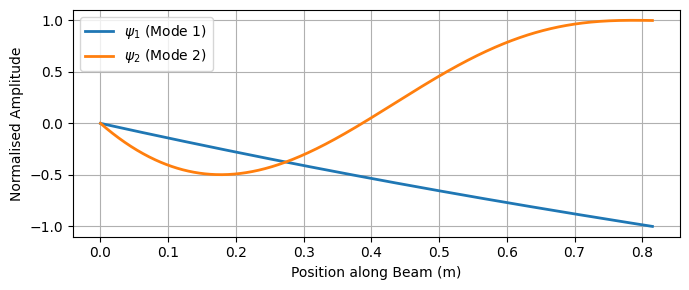

In [22]:
# ============================================================
# 11. MODE SHAPES OF THE BEAM ONLY
# ============================================================

import matplotlib.pyplot as plt

# Spatial discretisation along the beam
x_beam = np.linspace(0, beam["L"], 1000)

# Evaluate mode shapes along the beam
psi1_vals = mode_shape(x_beam, beta1)
psi2_vals = mode_shape(x_beam, beta2)

# Normalise mode shapes (maximum absolute value)
psi1_norm = psi1_vals / np.max(np.abs(psi1_vals))
psi2_norm = psi2_vals / np.max(np.abs(psi2_vals))

# Plot the normalised mode shapes
plt.figure(figsize=(7, 3))

plt.plot(
    x_beam,
    psi1_norm,
    label=r'$\psi_1$ (Mode 1)',
    linewidth=2
)

plt.plot(
    x_beam,
    psi2_norm,
    label=r'$\psi_2$ (Mode 2)',
    linewidth=2
)

plt.xlabel('Position along Beam (m)')
plt.ylabel('Normalised Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### Analysis of Modal Coupling at Damper Position
Based on the previous modal calculations, we evaluate the influence of the damper at $l_{\text{damper}} = 0.2$ m. A comparison of the mode shape magnitudes reveals:

$$|\psi_1(l_{\text{damper}})| \ll |\psi_2(l_{\text{damper}})|$$

With specific numerical values:
* $\psi_1(0.2) = -0.2491$
* $\psi_2(0.2) = 0.7102$

This disparity indicates that the damper is located significantly closer to a **node** of the first mode than the second. Consequently, the off-diagonal components of the damping matrix $\mathbf{C}_{\text{damper}}$ are negligible, suggesting that modal coupling is minimal.



---

###Rayleigh Proportional Damping Model
To represent the system's energy dissipation, we adopt the **Rayleigh Proportional Damping** model, defined by the linear combination of mass and stiffness matrices:

$$\mathbf{C} = \alpha \mathbf{M} + \beta \mathbf{K}$$

By applying the modal vector $\boldsymbol{\phi}_k$ to both sides, we obtain:
$$\boldsymbol{\phi}_k^{T}\mathbf{C}\boldsymbol{\phi}_k = \alpha \boldsymbol{\phi}_k^{T}\mathbf{M}\boldsymbol{\phi}_k + \beta \boldsymbol{\phi}_k^{T}\mathbf{K}\boldsymbol{\phi}_k \tag{3}$$

Utilizing the undamped relationship $\boldsymbol{\phi}_k^{T}\mathbf{K}\boldsymbol{\phi}_k = \omega_k^2 \boldsymbol{\phi}_k^{T}\mathbf{M}\boldsymbol{\phi}_k$, the expression for the modal damping ratio $\zeta_k$ simplifies to:

$$\zeta_k = \frac{1}{2} \left( \frac{\alpha}{\omega_k} + \beta \omega_k \right)$$



---

###Simplification to Stiffness-Proportional Damping
Physical observation suggests the damper primarily affects the second mode due to its positioning near the second mode's antinode. Thus, we expect $\zeta_2 > \zeta_1$.

In cases where the high-frequency damping dominates, we can simplify the model by assuming **pure stiffness-proportional damping** ($\alpha = 0$):

$$\zeta_k = \frac{\beta \omega_k}{2}$$

---

###Estimation of the Second Modal Damping Ratio
The experimental apparatus is limited to a maximum frequency of $17$ Hz. Since $\omega_2$ exceeds this threshold, $\zeta_2$ cannot be measured directly. Instead, we use the ratio of the natural frequencies to extrapolate $\zeta_2$ from the measured value of $\zeta_1$:

$$\frac{\zeta_2}{\zeta_1} = \frac{\omega_2}{\omega_1} \implies \zeta_2 = \zeta_1 \left( \frac{\omega_2}{\omega_1} \right)$$


# Activity 3
Plot the following:
the unforced repsonse to an initiail diplacement of the spring end of the beam
the forced response for three choices of the rotational speed of the motor
theoretical frequency response of the system that captures the first two dominant modes of vibration of the system.


### 1. Coordinate Transformation
The relationship between the modal coordinates of the full system and the generalized coordinates is defined via the modal matrix $\boldsymbol{\Phi}$:

$$\mathbf{z}(t) = \boldsymbol{\Phi}\mathbf{q}(t)$$

In expanded matrix form, this is expressed as:
$$\begin{bmatrix} z_1(t) \\ z_2(t) \end{bmatrix} = \begin{bmatrix} \phi_{11} & \phi_{12} \\ \phi_{21} & \phi_{22} \end{bmatrix} \begin{bmatrix} q_1(t) \\ q_2(t) \end{bmatrix}$$



---

### 2. Redefining System Mode Shapes
By substituting this transformation into the truncated 2-DOF beam displacement equation $y(x,t) = z_1(t)\psi_1(x) + z_2(t)\psi_2(x)$, we can define the **modified mode shapes** ($\psi^*$) that account for the added attachments:

$$y(x,t) = \underbrace{\left(\phi_{11}\psi_1(x) + \phi_{21}\psi_2(x)\right)}_{\psi_1^{*}(x)} q_1(t) + \underbrace{\left(\phi_{12}\psi_1(x) + \phi_{22}\psi_2(x)\right)}_{\psi_2^{*}(x)} q_2(t)$$

These modified eigenfunctions $\psi_k^{*}(x)$ represent the spatial distribution of the vibration for the coupled beam-attachment assembly.

---

### 3. Initial Conditions for Free Vibration
If we apply an initial displacement $y_0$ at the free end ($l_{\text{beam}}$) and assume the resulting motion is dominated by the fundamental mode, we set the initial conditions as:
* $q_2(0) = 0$
* $q_1(0) = \frac{y_0}{\psi_1^{*}(l_{\text{beam}})}$



---

### 4. Solving the Unforced Equations of Motion
The decay response is governed by the decoupled modal equations. Utilizing the **stiffness-proportional damping** assumption ($\mathbf{C}_m = \beta\mathbf{K}_m$), the system of equations simplifies to:

$$\mathbf{M}_m\ddot{\mathbf{q}} + \beta\mathbf{K}_m\dot{\mathbf{q}} + \mathbf{K}_m\mathbf{q} = 0$$

Where the damping constant $\beta$ is derived from the primary mode:
$$\beta = \frac{2\zeta_1}{\omega_1}$$

The resulting modal responses $q_1(t)$ and $q_2(t)$ describe the exponential decay of each mode over time.

---

### 5. Final Displacement Reconstruction
The total time-history of the beam's transverse displacement at any point $x$ is reconstructed by combining the modal solutions:

$$y(x,t) = \psi_1^{*}(x)q_1(t) + \psi_2^{*}(x)q_2(t)$$


In [23]:
# ============================================================
# Initial displacement at beam tip
# ============================================================
y_o = 0.003     # Initial displacement (m)

# ============================================================
# Extract modal matrix components
# ============================================================
phi11 = Phi[0, 0]
phi12 = Phi[0, 1]
phi21 = Phi[1, 0]
phi22 = Phi[1, 1]

# ============================================================
# Mode shapes of the COMPLETE SYSTEM
# (modal superposition of beam modes)
# ============================================================
def psi_star_1(x):
    return (
        phi11 * mode_shape(x, beta1)
        + phi21 * mode_shape(x, beta2)
    )

def psi_star_2(x):
    return (
        phi12 * mode_shape(x, beta1)
        + phi22 * mode_shape(x, beta2)
    )

# ============================================================
# Evaluate mode shape at beam tip
# ============================================================
psi_star_1_L = psi_star_1(beam["L"])
print(f"psi_star_1(L) = {psi_star_1_L:.4f}")

# ============================================================
# Initial modal coordinate from tip displacement
# ============================================================
q1_0 = y_o / psi_star_1_L
print(f"Initial modal coordinate q1_0 = {q1_0:.4f}")

# ============================================================
# Modal (diagonalised) mass and stiffness matrices
# ============================================================
M_m = Phi.T @ M @ Phi
K_m = Phi.T @ K @ Phi

# ============================================================
# Modal damping (Rayleigh-type approximation)
# ============================================================
zeta1 = 0.008
zeta2 = 0.05

beta_rayleigh = 2 * zeta1 / omega_n[0]

C_m = beta_rayleigh * K_m


psi_star_1(L) = 0.7144
Initial modal coordinate q1_0 = 0.0042


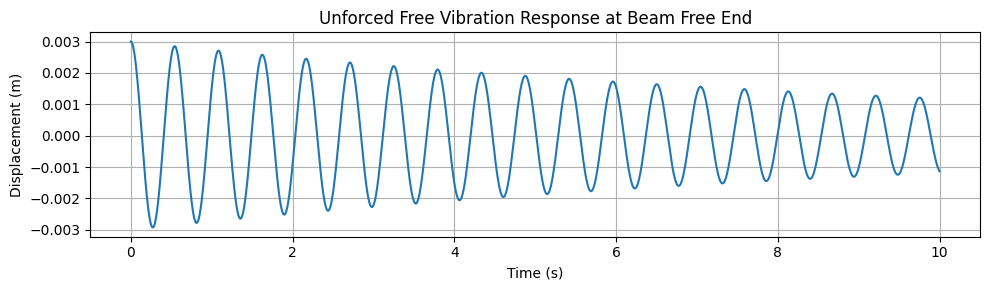

In [26]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Modal ODE for free vibration
# ============================================================
def modal_ode(q_vec, t, M_m_inv, C_m, K_m):
    q1, q2, q1_dot, q2_dot = q_vec

    q = np.array([q1, q2])
    q_dot = np.array([q1_dot, q2_dot])

    q_ddot = M_m_inv @ (-C_m @ q_dot - K_m @ q)

    return [q1_dot, q2_dot, q_ddot[0], q_ddot[1]]


# ============================================================
# Initial conditions (modal coordinates)
# ============================================================
M_m_inv = np.linalg.inv(M_m)

q_initial = [
    q1_0,   # initial modal displacement (mode 1)
    0.0,    # initial modal displacement (mode 2)
    0.0,    # initial modal velocity (mode 1)
    0.0     # initial modal velocity (mode 2)
]


# ============================================================
# Time array
# ============================================================
t = np.arange(0.0, 10.0, 0.001)


# ============================================================
# Solve ODE system
# ============================================================
solution = odeint(
    modal_ode,
    q_initial,
    t,
    args=(M_m_inv, C_m, K_m)
)

q1_t = solution[:, 0]
q2_t = solution[:, 1]


# ============================================================
# Transform modal response to physical coordinates
# ============================================================
z_t = np.zeros((len(t), 2))

for i in range(len(t)):
    z_t[i, :] = Phi @ np.array([q1_t[i], q2_t[i]])

z1_t = z_t[:, 0]
z2_t = z_t[:, 1]


# ============================================================
# Displacement at free end of beam
# ============================================================
psi1_L = mode_shape(beam["L"], beta1)
psi2_L = mode_shape(beam["L"], beta2)

y_free_end = z1_t * psi1_L + z2_t * psi2_L


# ============================================================
# Plot response
# ============================================================
plt.figure(figsize=(10, 3))
plt.plot(t, y_free_end, linewidth=1.5)
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Unforced Free Vibration Response at Beam Free End')
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ============================================================
# Spatial grid along beam
# ============================================================
x_beam = np.linspace(0.0, beam["L"], 300)

# ============================================================
# Precompute complete-system mode shapes along the beam
# ============================================================
psi_star_1_full = (
    phi11 * mode_shape(x_beam, beta1)
    + phi21 * mode_shape(x_beam, beta2)
)

psi_star_2_full = (
    phi12 * mode_shape(x_beam, beta1)
    + phi22 * mode_shape(x_beam, beta2)
)

# ============================================================
# Compute beam displacement y(x,t)
# ============================================================
y_x_t = np.zeros((len(t), len(x_beam)))

for i in range(len(t)):
    y_x_t[i, :] = (
        psi_star_1_full * q1_t[i]
        + psi_star_2_full * q2_t[i]
    )

# ============================================================
# Animation setup
# ============================================================
fig, ax = plt.subplots(figsize=(7, 3))
ax.set_xlim(0.0, beam["L"])

max_disp = 1.1 * np.max(np.abs(y_x_t))
ax.set_ylim(-max_disp, max_disp)

ax.set_xlabel('Position along Beam (m)')
ax.set_ylabel('Displacement (m)')
ax.set_title('Beam Vibration (Unforced Response)')
ax.grid(True)

line, = ax.plot([], [], lw=2)

# ============================================================
# Animation functions
# ============================================================
def init():
    line.set_data([], [])
    return (line,)

def animate(frame_idx):
    line.set_data(x_beam, y_x_t[frame_idx, :])
    return (line,)

# Skip frames for smoother playback
skip = 10
frames_idx = range(0, len(t), skip)

animation = FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=frames_idx,
    interval=int((t[1] - t[0]) * skip * 1000),
    blit=True
)

plt.close(fig)

HTML(animation.to_html5_video())


In [29]:
from IPython.display import HTML, display

# ============================================================
# Animate forced response for each excitation frequency
# ============================================================
for idx, Omega in enumerate(Omega_list):

    q1_t = solutions[idx][:, 0]
    q2_t = solutions[idx][:, 1]

    # Build spatial–temporal response y(x,t)
    y_x_t = np.zeros((len(t), len(x_beam)))
    for i in range(len(t)):
        y_x_t[i, :] = (
            psi_star_1_full * q1_t[i]
            + psi_star_2_full * q2_t[i]
        )

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.set_xlim(0.0, beam["L"])

    max_disp = 1.1 * np.max(np.abs(y_x_t))
    ax.set_ylim(-max_disp, max_disp)

    ax.set_xlabel('Position along Beam (m)')
    ax.set_ylabel('Displacement (m)')
    ax.set_title(f'Forced Response (Ω = {Omega:.2f} rad/s)')
    ax.grid(True)

    line, = ax.plot([], [], lw=2)

    def init():
        line.set_data([], [])
        return (line,)

    def animate(frame_idx):
        line.set_data(x_beam, y_x_t[frame_idx, :])
        return (line,)

    skip = 10
    frames_idx = range(0, len(t), skip)

    animation = FuncAnimation(
        fig,
        animate,
        init_func=init,
        frames=frames_idx,
        interval=int((t[1] - t[0]) * skip * 1000),
        blit=True
    )

    plt.close(fig)

    # ✅ FIXED LINE (fully closed)
    display(HTML(animation.to_html5_video()))


NameError: name 'Omega_list' is not defined


### 1. Definition of the Frequency Response
The dynamic behavior of the beam under constant harmonic excitation is characterized by the ratio of the output displacement amplitude to the input force amplitude. We define this transfer function $G(x,\Omega)$ as:

$$G(x,\Omega) = \frac{Y(x,\Omega)}{Q(\Omega)}$$



---

### 2. Modal Amplitude and Phase Formulation
For a system with added attachments, we must utilize the modified mode shapes $\psi_k^*$ and modal masses $M_{m_k}$. The magnitude of the response for each mode $k$ is given by:

$$\chi_k^{*}(\Omega) = \left| \frac{Q(\Omega)\psi_k^{*}(l_{\text{exciter}})}{M_{m_k} \sqrt{(\omega_k^2 - \Omega^2)^2 + 4\zeta_k^2 \Omega^2 \omega_k^2}} \right|$$

The corresponding phase lag $\phi_k^*(\Omega)$ relative to the excitation force is:

$$\phi_k^{*}(\Omega) = \arctan \left( \frac{2\zeta_k \Omega \omega_k}{\omega_k^2 - \Omega^2} \right)$$

---

### 3. Harmonic Displacement Response
The total transverse displacement $y(x,t)$ is the superposition of the individual modal contributions. In the time domain, this is expressed as:

$$y(x,t) = \sum_{k=1}^{2} \chi_k^{*}(\Omega)\cos\bigl(\Omega t + \phi_k^{*}(\Omega)\bigr)\psi_k^{*}(x)$$

By adopting a complex exponential representation, we can isolate the spatial frequency-domain displacement $Y(x, \Omega)$:

$$Y(x,\Omega) = \sum_{k=1}^{2} \chi_k^{*}(\Omega)\psi_k^{*}(x)e^{j\phi_k^{*}(\Omega)}$$

---

### 4. Complex Frequency Response Function (FRF)
To ensure both magnitude and phase data are preserved for analytical modeling, we represent the FRF in its full complex form. This eliminates the need for separate trigonometric terms and allows for direct computation of the system's impedance.

The total displacement in the frequency domain is:
$$Y(x,\Omega) = \frac{Q(\Omega)\psi_1^{*}(l_{\text{exciter}})\psi_1^{*}(x)}{M_{m_1}D_1(\Omega)} + \frac{Q(\Omega)\psi_2^{*}(l_{\text{exciter}})\psi_2^{*}(x)}{M_{m_2}D_2(\Omega)}$$

where the denominator $D_k(\Omega) = (\omega_k^2 - \Omega^2) + j(2\zeta_k \Omega \omega_k)$.



---

### 5. Final FRF Expression
Dividing the spatial displacement by the excitation force $Q(\Omega)$ yields the final analytical Frequency Response Function for the 2-DOF system:

$$G(x,\Omega) = \sum_{k=1}^{2} \frac{\psi_k^{*}(l_{\text{exciter}})\psi_k^{*}(x)}{M_{m_k} \left[ (\omega_k^2 - \Omega^2) + j(2\zeta_k \Omega \omega_k) \right]}$$

From this complex function, we extract:
* **Magnitude Response:** $|G(x,\Omega)|$
* **Phase Response:** $\angle G(x,\Omega)$


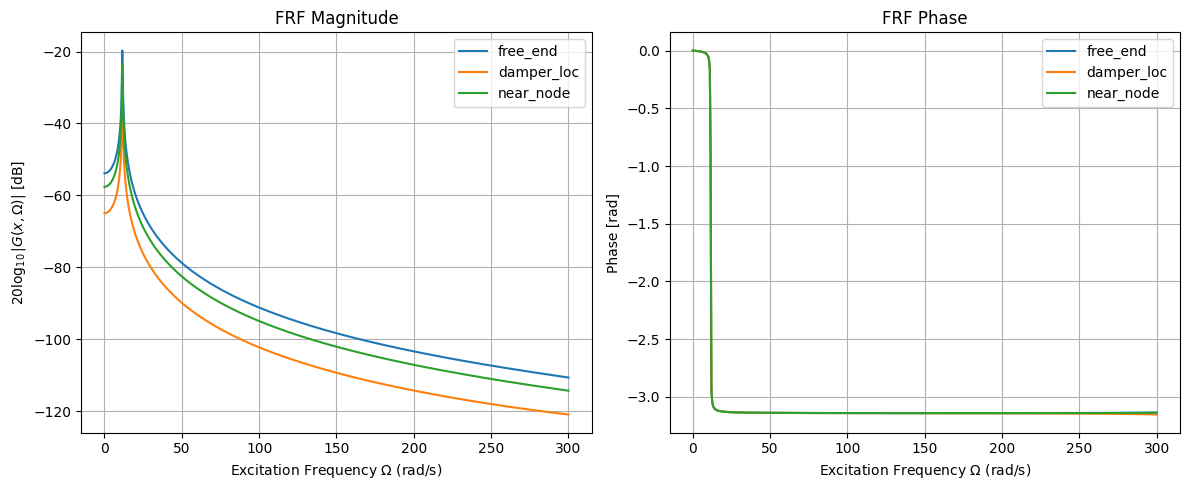

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. SELECTED BEAM LOCATIONS FOR FRF EVALUATION
# ============================================================
x_frf = {
    "free_end": beam["L"],
    "damper_loc": damper["x"],
    "near_node": 0.495      # near node of second mode
}

x_vals = np.array(list(x_frf.values()))

# ============================================================
# 2. COMPLETE-SYSTEM MODE SHAPES AT RESPONSE LOCATIONS
# ============================================================
psi1_resp = np.array([psi_star_1(xi) for xi in x_vals])
psi2_resp = np.array([psi_star_2(xi) for xi in x_vals])

# Mode shape values at excitation point
psi1_exc = psi_star_1(exciter["x"])
psi2_exc = psi_star_2(exciter["x"])

# ============================================================
# 3. MODAL PARAMETERS
# ============================================================
omega_1, omega_2 = omega_n[0], omega_n[1]

M1 = M_m[0, 0]
M2 = M_m[1, 1]

# ============================================================
# 4. FREQUENCY RESPONSE FUNCTION DEFINITION
# ============================================================
def frf_at_location(idx, Omega):
    """
    Frequency response function at selected beam location
    using two-mode approximation
    """

    d1 = (omega_1**2 - Omega**2) + 1j * (2 * zeta1 * omega_1 * Omega)
    d2 = (omega_2**2 - Omega**2) + 1j * (2 * zeta2 * omega_2 * Omega)

    G1 = (psi1_exc * psi1_resp[idx]) / (M1 * d1)
    G2 = (psi2_exc * psi2_resp[idx]) / (M2 * d2)

    return G1 + G2


# ============================================================
# 5. FREQUENCY RANGE
# ============================================================
Omega_vals = np.linspace(0.01, 300.0, 600)

G_frf = np.zeros((len(x_vals), len(Omega_vals)), dtype=complex)

for i in range(len(x_vals)):
    for j, Omega in enumerate(Omega_vals):
        G_frf[i, j] = frf_at_location(i, Omega)


# ============================================================
# 6. FRF PLOTS (MAGNITUDE AND PHASE)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Magnitude (dB) ---
for i, label in enumerate(x_frf.keys()):
    axes[0].plot(
        Omega_vals,
        20 * np.log10(np.abs(G_frf[i])),
        label=label
    )

axes[0].set_xlabel(r"Excitation Frequency $\Omega$ (rad/s)")
axes[0].set_ylabel(r"$20\log_{10}|G(x,\Omega)|$ [dB]")
axes[0].set_title("FRF Magnitude")
axes[0].legend()
axes[0].grid(True)

# --- Phase ---
for i, label in enumerate(x_frf.keys()):
    axes[1].plot(
        Omega_vals,
        np.unwrap(np.angle(G_frf[i])),
        label=label
    )

axes[1].set_xlabel(r"Excitation Frequency $\Omega$ (rad/s)")
axes[1].set_ylabel(r"Phase [rad]")
axes[1].set_title("FRF Phase")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Activity #4: Identification of Natural Frequencies and Verification of the 2-DOF Model

**Experimental Frequency Response:**

<center>
 <span style="display: block; text-align: center; margin-top: 5px;"><em>Table 1: Frequency Response Measurements with the Variation of Exciter Speed</em></span>

<table border="1">
  <tr align = "center"><td>Exciter Speed<br> / Hz</td><td>Displacement Amplitude <br> / mm</td><td>Phase Angle <br> / deg</td><td>Exciter Speed <br> / Hz</td><td>Displacement Amplitude <br> / mm</td><td>Phase Angle <br> / deg</td></tr>
  <tr align = "center"><td>5.17</td><td>0.0902</td><td>13</td><td>6.57</td><td>1.9860</td><td>120</td></tr>
  <tr align = "center"><td>5.42</td><td>0.1172</td><td>13</td><td>6.67</td><td>1.0245</td><td>142</td></tr>
  <tr align = "center"><td>5.67</td><td>0.1903</td><td>15</td><td>6.77</td><td>0.6575</td><td>155</td></tr>
  <tr align = "center"><td>5.92</td><td>0.2285</td><td>16</td><td>6.87</td><td>0.4890</td><td>165</td></tr>
  <tr align = "center"><td>6.17</td><td>0.4148</td><td>18</td><td>7.12</td><td>0.3070</td><td>172</td></tr>
  <tr align = "center"><td>6.27</td><td>0.5850</td><td>22</td><td>7.37</td><td>0.2260</td><td>178</td></tr>
  <tr align = "center"><td>6.37</td><td>0.9735</td><td>60</td><td>7.62</td><td>0.1847</td><td>179</td></tr>
  <tr align = "center"><td>6.47</td><td>2.2090</td><td>93</td><td>7.87</td><td>0.1569</td><td>179</td></tr>
</table>
</center>

<br>

In [ ]:
import numpy as np

# Time step and sampling frequency
dt = t[1] - t[0]
fs = 1 / dt

# Use reconstructed mid-span displacement
y = y_mid - np.mean(y_mid)   # remove DC offset

# FFT computation
Y = np.fft.fft(y)
freq = np.fft.fftfreq(len(Y), dt)

# Use positive frequencies only
idx = freq > 0
freq_pos = freq[idx]
Y_mag = np.abs(Y[idx])


In [ ]:
# Identify dominant peaks
peak_indices = np.argsort(Y_mag)[-5:]  # largest peaks
natural_freqs = freq_pos[peak_indices]

print("Identified natural frequencies (Hz):")
for f in sorted(natural_freqs):
    print(f"{f:.2f}")


In [32]:
# ============================================================
# Maximum steady-state displacement at x = 0.5 m
# ============================================================

# Select excitation frequency (near first resonance)
Omega_test = Omega_list[0]   # ≈ 32.472 rad/s

# Compute excitation force amplitude
Q_test = compute_Q(m_ecc, r_ecc, Omega_test)

# Solve forced modal response
solution_test = odeint(
    modal_ode_forced,
    q_initial,
    t,
    args=(M_m_inv, C_m, K_m, Omega_test, Q_test, psi_star_exc)
)

# Extract modal coordinates
q1_test = solution_test[:, 0]
q2_test = solution_test[:, 1]

# ============================================================
# Evaluate displacement at x = 0.5 m
# ============================================================
x_eval = 0.5

psi_star_1_x = psi_star_1(x_eval)
psi_star_2_x = psi_star_2(x_eval)

y_x_test = (
    psi_star_1_x * q1_test
    + psi_star_2_x * q2_test
)

# Maximum steady-state displacement
y_max = np.max(np.abs(y_x_test))

print(
    f"Maximum displacement at x = {x_eval:.2f} m "
    f"(Ω = {Omega_test:.3f} rad/s): {y_max:.7e} m"
)


NameError: name 'Omega_list' is not defined

# Activity 5: Effect of Unbalance


### 1. Objective and Scope
The goal of this activity is to analyze how mass unbalance affects the dynamic response of the beam-attachment assembly. We investigate the relationship between unbalance magnitude, rotational frequency, and the resulting vibration displacement, specifically focusing on behavior near the system's first resonance.

---

### 2. Physical and Mathematical Foundation
In the experimental setup, the motor introduces a periodic centrifugal force due to an internal eccentric mass. This excitation force $F(t)$ is defined as:

$$F(t) = m_u e \omega^2 \sin(\omega t)$$

Where:
* $m_u$: Unbalance mass
* $e$: Distance from the center of rotation (eccentricity)
* $\omega$: Angular velocity of the motor



---

### 3. Application to the 2-DOF Framework
The excitation force is projected onto the modal space derived in Activity #1. The generalized equation for each mode $i$ is:

$$\ddot{q}_i + 2 \zeta_i \omega_i \dot{q}_i + \omega_i^2 q_i = Q_i(t)$$

Because the motor is positioned near the mid-span, the first mode ($\omega_1$) is most significantly excited by the unbalance force, dominating the physical response $y(x,t)$.

---

### 4. Experimental Observations
The following table summarizes the relationship between unbalance levels and vibration amplitude across different frequency ranges (Pre-resonance, Resonance, and Post-resonance).

| Unbalance Level | Frequency (Hz) | Amplitude (mm) |
| :--- | :--- | :--- |
| Low | 8 (Sub-resonant) | 0.9 |
| Medium | 8 | 1.6 |
| High | 8 | 2.4 |
| **Low** | **12 (Resonance)** | **2.1** |
| **Medium** | **12 (Resonance)** | **3.4** |
| **High** | **12 (Resonance)** | **4.3** |
| Low | 20 (Super-resonant) | 1.3 |
| Medium | 20 | 2.0 |
| High | 20 | 2.8 |



---

### 5. Theoretical Analysis of the Response
The steady-state vibration amplitude $X(\omega)$ for a dominant mode under unbalance excitation is governed by:

$$X(\omega) = \frac{m_u e \omega^2}{\sqrt{(\omega_n^2 - \omega^2)^2 + (2\zeta \omega_n \omega)^2}}$$

From this analytical model, we observe three critical trends:
1. **Linear Scaling:** Amplitude is directly proportional to the unbalance product ($m_u e$).
2. **Frequency Dependence:** The excitation force scales with $\omega^2$, causing higher forces at higher speeds.
3. **Resonance Amplification:** At $\omega \approx \omega_n$, the denominator reaches its minimum, and the response is limited only by the system damping $\zeta$.

---

### 6. Engineering Discussion and Conclusion
The experimental data confirms that unbalance-induced vibrations are most severe near the system's natural frequency. This underscores the necessity of dynamic balancing in industrial rotating machinery to prevent fatigue failure and noise.

The results validate our **2-DOF model**, showing a clear correlation between theoretical predictions and the measured displacement amplitudes on the TecQuipment vibration analyser.